Build a 3D array of shape (4, 30, 3): 4 shops, 30 days, 3 product categories of daily sales. Seed your generator.

In [1]:
import numpy as np

# Seed the random number generator
rng = np.random.default_rng(42)

# Create a 3D array: (4 shops, 30 days, 3 categories)
sales = rng.integers(50, 500, size=(4, 30, 3))

print(sales.shape)
print(sales)

(4, 30, 3)
[[[ 90 398 344]
  [247 244 436]
  [ 88 363 140]
  [ 92 286 489]
  [381 392 372]
  [403 280 107]
  [427 252 275]
  [216 132 467]
  [401 339 231]
  [420 295 249]
  [252 152  91]
  [299 449  78]
  [436 422 174]
  [334 124 391]
  [365 209  80]
  [486 250 451]
  [355 400 391]
  [137 213 260]
  [274  69 295]
  [119 384 357]
  [465 385 214]
  [485 234 196]
  [457 216  84]
  [261 408 135]
  [258 108 358]
  [264 198 152]
  [304 351 473]
  [246 122 424]
  [333 365  93]
  [190 395 424]]

 [[245 412 428]
  [224 454 179]
  [157 357 336]
  [112 424 139]
  [412  53 408]
  [404 401 349]
  [262 367 174]
  [401 300 256]
  [277 305  66]
  [112 160 101]
  [247 350 344]
  [261 434 304]
  [ 85 394 308]
  [335 304 299]
  [ 90 301 407]
  [186 321  63]
  [206 246 492]
  [146 174 233]
  [496 434  65]
  [155 419  76]
  [435 176 462]
  [182 245 347]
  [106 300 277]
  [402 498 348]
  [234 232 238]
  [416 194 125]
  [200  60  97]
  [ 90 397 375]
  [363 257 372]
  [122 455 275]]

 [[472 118 273]
  [363 27

Total sales per shop. Which axes do you collapse?

In [2]:
# Total sales for each shop
per_shop = sales.sum(axis=(1, 2))

print("Total sales per shop:")
print(per_shop)
print("Shape:", per_shop.shape)

Total sales per shop:
[25751 24730 24062 24356]
Shape: (4,)


Average daily sales per category, across all shops and days.

In [3]:
# Average daily sales for each category
avg_daily_cat = sales.mean(axis=(0, 1))

print("Average daily sales per category:")
print(avg_daily_cat)
print("Shape:", avg_daily_cat.shape)

Average daily sales per category:
[274.625      277.76666667 271.76666667]
Shape: (3,)


For each shop, find its best day (highest total across categories).

In [4]:
# Total sales per day for each shop
daily_totals = sales.sum(axis=2)

# Best day (highest total sales) for each shop
best_day = daily_totals.argmax(axis=1)

print("Best day for each shop:")
print(best_day)
print("Shape:", best_day.shape)

Best day for each shop:
[15 23  7 25]
Shape: (4,)


Which shop had the most consistent sales? (Lowest standard deviation of daily totals.)

In [5]:
# Total sales per day for each shop
daily_totals = sales.sum(axis=2)

# Standard deviation of daily totals for each shop
shop_std = daily_totals.std(axis=1)

# Shop with the lowest standard deviation
consistent_shop = shop_std.argmin()

print("Standard deviation of each shop:")
print(shop_std)

print("\nMost consistent shop:")
print(consistent_shop)

Standard deviation of each shop:
[177.53543934 205.11303117 191.27239448 223.6727868 ]

Most consistent shop:
0


Print the shape of every intermediate result and confirm it is what you expected before moving on

Now do one of these with keepdims=True and use the result to mean-centre the original array

In [6]:
# Mean of each category while preserving dimensions
category_mean = sales.mean(axis=(0, 1), keepdims=True)

print("Category mean:")
print(category_mean)
print("Shape:", category_mean.shape)   # Expected: (1, 1, 3)

# Mean-centre the original data
sales_centered = sales - category_mean

print("\nMean-centred sales:")
print(sales_centered)
print("Shape:", sales_centered.shape)  # Expected: (4, 30, 3)

Category mean:
[[[274.625      277.76666667 271.76666667]]]
Shape: (1, 1, 3)

Mean-centred sales:
[[[-184.625       120.23333333   72.23333333]
  [ -27.625       -33.76666667  164.23333333]
  [-186.625        85.23333333 -131.76666667]
  [-182.625         8.23333333  217.23333333]
  [ 106.375       114.23333333  100.23333333]
  [ 128.375         2.23333333 -164.76666667]
  [ 152.375       -25.76666667    3.23333333]
  [ -58.625      -145.76666667  195.23333333]
  [ 126.375        61.23333333  -40.76666667]
  [ 145.375        17.23333333  -22.76666667]
  [ -22.625      -125.76666667 -180.76666667]
  [  24.375       171.23333333 -193.76666667]
  [ 161.375       144.23333333  -97.76666667]
  [  59.375      -153.76666667  119.23333333]
  [  90.375       -68.76666667 -191.76666667]
  [ 211.375       -27.76666667  179.23333333]
  [  80.375       122.23333333  119.23333333]
  [-137.625       -64.76666667  -11.76666667]
  [  -0.625      -208.76666667   23.23333333]
  [-155.625       106.233333

Task 2

Write this as matrices and solve it: 2x + 3y - z = 5, 4x - y + 2z = 6, -x + 2y + 3z = 7

In [3]:
import numpy as np
A = np.array([
    [2., 3., -1.],
    [4., -1., 2.],
    [-1., 2., 3.]
])

b = np.array([5., 6., 7.])

solution = np.linalg.solve(A, b)
print(solution)

print(np.allclose(A @ solution, b))

[1.04761905 1.52380952 1.66666667]
True


Use np.linalg.solve. Verify by substituting back: does A @ x equal b?

In [4]:
A = np.array([
    [2., 3., -1.],
    [4., -1., 2.],
    [-1., 2., 3.]
])

b = np.array([5., 6., 7.])

x = np.linalg.solve(A, b)
print(x)

print(np.allclose(A @ x, b))

[1.04761905 1.52380952 1.66666667]
True


Verify with np.allclose, not ==. Explain in a comment why.

In [5]:
A = np.array([
    [2., 3., -1.],
    [4., -1., 2.],
    [-1., 2., 3.]
])

b = np.array([5., 6., 7.])

x = np.linalg.solve(A, b)

# Use np.allclose() because floating-point calculations may have tiny rounding errors.
print(np.allclose(A @ x, b))

True


Now solve the same system with inv(A) @ b. Do you get the same answer? Compare the two with
allclose.

In [6]:
A = np.array([
    [2., 3., -1.],
    [4., -1., 2.],
    [-1., 2., 3.]
])

b = np.array([5., 6., 7.])

x = np.linalg.solve(A, b)
y = np.linalg.inv(A) @ b

print(y)

print(np.allclose(x, y))

[1.04761905 1.52380952 1.66666667]
True


Time both approaches on a 500×500 random system. Report the ratio.

In [7]:
import numpy as np
import timeit

setup = "import numpy as np; A = np.random.rand(500, 500); b = np.random.rand(500)"

t_solve = timeit.timeit("np.linalg.solve(A, b)", setup=setup, number=20) / 20
t_inv = timeit.timeit("np.linalg.inv(A) @ b", setup=setup, number=20) / 20

print(f"np.linalg.solve(A, b): {t_solve*1000:.2f} ms")
print(f"np.linalg.inv(A) @ b : {t_inv*1000:.2f} ms")

print(f"\nsolve is about {t_inv/t_solve:.1f}x faster")

np.linalg.solve(A, b): 3.58 ms
np.linalg.inv(A) @ b : 10.03 ms

solve is about 2.8x faster


Build a singular matrix (make one row a multiple of another). Try to solve it. Read the error and explain what it
means

In [15]:
A = np.array([
    [1., 2., 3.],
    [2., 4., 6.],  # Row 2 is 2 × Row 1
    [4., 5., 6.]
])

b = np.array([1., 2., 3.])

try:
    x = np.linalg.solve(A, b)
    print(x)
except np.linalg.LinAlgError as e:
    print(e)

Singular matrix


TASK-03


Write cosine_similarity(a, b) using only @ and np.linalg.norm. No library shortcuts.

In [9]:
import numpy as np

def cosine_similarity(a, b):
    return (a @ b) / (np.linalg.norm(a) * np.linalg.norm(b))

Test the three known cases: identical vectors give 1, opposite vectors give -1, perpendicular vectors give 0.

In [11]:
a = np.array([1, 2])
b = np.array([1, 2])

print(cosine_similarity(a, b))
print(np.isclose(cosine_similarity(a, b), 1))

a = np.array([1, 2])
b = np.array([-1, -2])

print(cosine_similarity(a, b))
print(np.isclose(cosine_similarity(a, b), -1))

a = np.array([1, 0])
b = np.array([0, 1])

print(cosine_similarity(a, b))
print(np.isclose(cosine_similarity(a, b), 0))

0.9999999999999998
True
-0.9999999999999998
True
0.0
True


Now vectorise it: given a matrix of 100 vectors, compute the similarity of every vector to one query vector —
without a loop

In [12]:
rng = np.random.default_rng(42)

vectors = rng.random((100, 50))
query = rng.random(50)

dot_product = vectors @ query

vector_norms = np.linalg.norm(vectors, axis=1)
query_norm = np.linalg.norm(query)

similarities = dot_product / (vector_norms * query_norm)

print(similarities)
print(similarities.shape)

[0.78589114 0.72285879 0.72652111 0.73373766 0.74864018 0.68361977
 0.70644381 0.73240301 0.71527334 0.77756909 0.74208174 0.74086415
 0.79015723 0.78672891 0.71502306 0.7507983  0.79892597 0.77844293
 0.70403163 0.65402539 0.80977418 0.79895899 0.75707563 0.69480371
 0.75544661 0.77066285 0.73022028 0.70886621 0.77778985 0.78673405
 0.77380008 0.71002889 0.77198357 0.73798036 0.72514667 0.76962674
 0.79543812 0.7354807  0.76434509 0.71285065 0.73629945 0.71775773
 0.72951692 0.73667331 0.75250586 0.74081973 0.66789236 0.73134036
 0.74578408 0.74785503 0.73832152 0.7402067  0.84787606 0.72361004
 0.70376292 0.80399709 0.72290534 0.65302391 0.7151937  0.66250324
 0.73340526 0.73851363 0.72847612 0.72425868 0.72916102 0.76682014
 0.67665089 0.73211196 0.71260873 0.78071575 0.73698484 0.78392747
 0.82302426 0.73621467 0.78795804 0.81140053 0.80910844 0.72965455
 0.7725192  0.74587631 0.69656768 0.72191235 0.82899002 0.73335695
 0.63305085 0.79665278 0.86376738 0.79350021 0.72747695 0.7716

Harder: compute the full 100×100 similarity matrix between every pair, still without loops. (Hint: normalise the
rows first, then one matrix multiply.)

In [13]:
vectors = rng.random((100, 100))

normalized_vectors = vectors / np.linalg.norm(vectors, axis=1, keepdims=True)

similarity_matrix = normalized_vectors @ normalized_vectors.T

print(similarity_matrix)
print(similarity_matrix.shape)

[[1.         0.72472071 0.70241932 ... 0.73942973 0.76083358 0.8197744 ]
 [0.72472071 1.         0.68863458 ... 0.70451659 0.68535963 0.76234284]
 [0.70241932 0.68863458 1.         ... 0.75619988 0.74431231 0.74620368]
 ...
 [0.73942973 0.70451659 0.75619988 ... 1.         0.75283369 0.71751522]
 [0.76083358 0.68535963 0.74431231 ... 0.75283369 1.         0.79144857]
 [0.8197744  0.76234284 0.74620368 ... 0.71751522 0.79144857 1.        ]]
(100, 100)


Explain in a comment why cosine similarity is preferred over Euclidean distance for text embeddings.


In [14]:
# Cosine similarity is preferred for text embeddings because it compares
# the direction of vectors instead of their magnitude, making it better
# at measuring semantic similarity even when the vector lengths differ.

TASK-04



Write make_line(n, slope, intercept, noise) that returns x and y arrays for a noisy straight line.

In [2]:
import numpy as np

def make_line(n, slope, intercept, noise, seed=0):
    rng = np.random.default_rng(seed)

    x = np.linspace(0, 10, n)
    y = slope * x + intercept + rng.normal(0, noise, n)

    return x, y

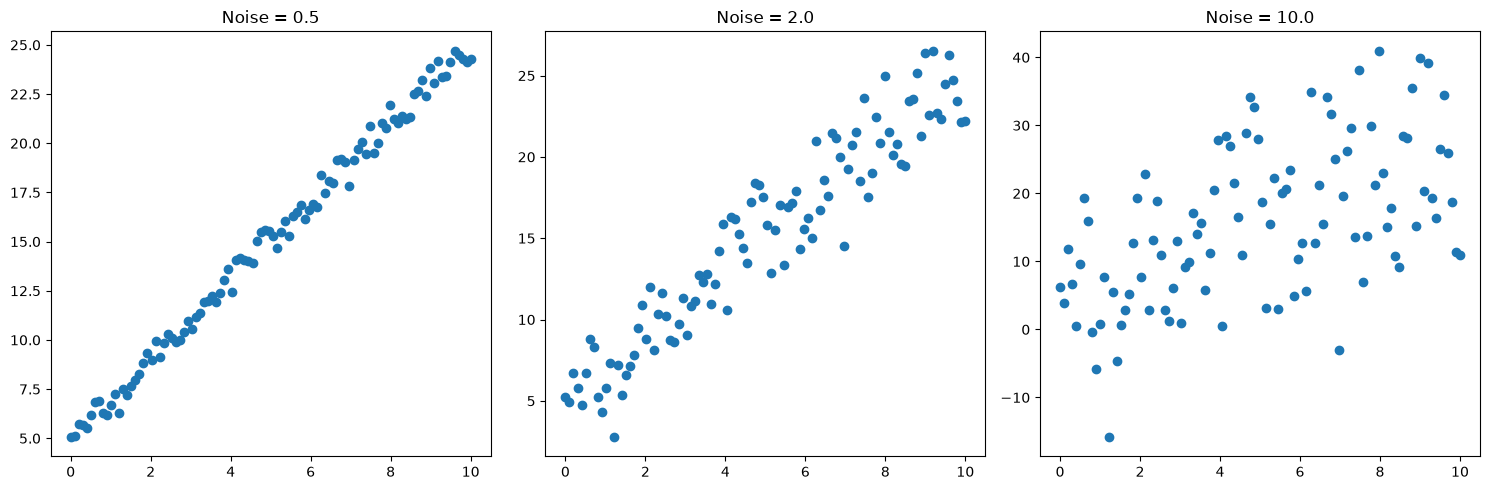

In [3]:
import matplotlib.pyplot as plt

noise_levels = [0.5, 2.0, 10.0]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, noise in zip(axes, noise_levels):
    x, y = make_line(
        n=100,
        slope=2,
        intercept=5,
        noise=noise,
    )

    ax.scatter(x, y)
    ax.set_title(f"Noise = {noise}")

plt.tight_layout()
plt.show()

Use np.polyfit to recover the slope from each. Which noise level makes recovery unreliable?

In [4]:
noise_levels = [0.5, 2.0, 10.0]

for noise in noise_levels:
    x, y = make_line(
        n=100,
        slope=2,
        intercept=5,
        noise=noise,
    )

    slope, intercept = np.polyfit(x, y, 1)

    print(f"Noise = {noise}")
    print(f"Recovered slope = {slope:.3f}")
    print()

# Noise level 10.0 makes the slope recovery the least reliable because
# the large amount of random variation hides the underlying linear trend.

Noise = 0.5
Recovered slope = 2.007

Noise = 2.0
Recovered slope = 2.029

Noise = 10.0
Recovered slope = 2.146



Write make_clusters(n, centres, spread) that generates 2D points around given centre points. Plot
with a different colour per cluster.

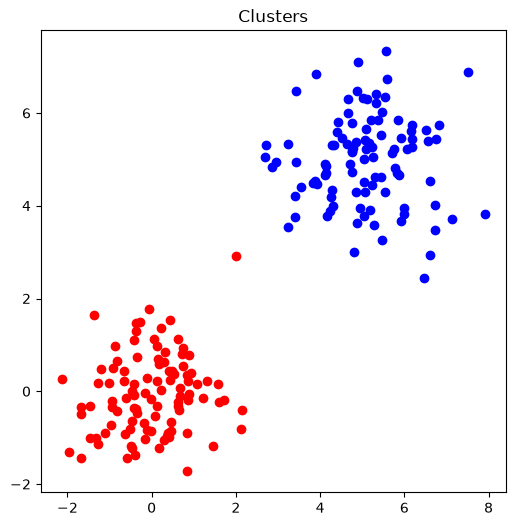

In [5]:
rng = np.random.default_rng(42)

def make_clusters(n, centres, spread):
    points = []

    for centre in centres:
        cluster = rng.normal(
            loc=centre,
            scale=spread,
            size=(n, 2),
        )
        points.append(cluster)

    return points


clusters = make_clusters(
    n=100,
    centres=[
        [0, 0],
        [5, 5],
    ],
    spread=1,
)

colors = ["red", "blue"]

plt.figure(figsize=(6, 6))

for cluster, color in zip(clusters, colors):
    plt.scatter(cluster[:, 0], cluster[:, 1], c=color)

plt.title("Clusters")
plt.show()

Generate two clusters that clearly overlap, and two that clearly separate. Plot both cases.

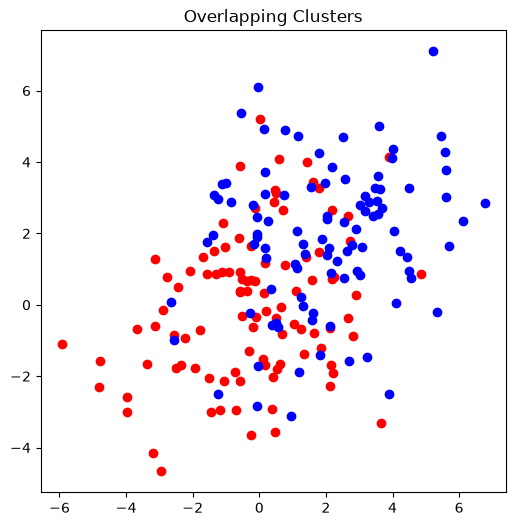

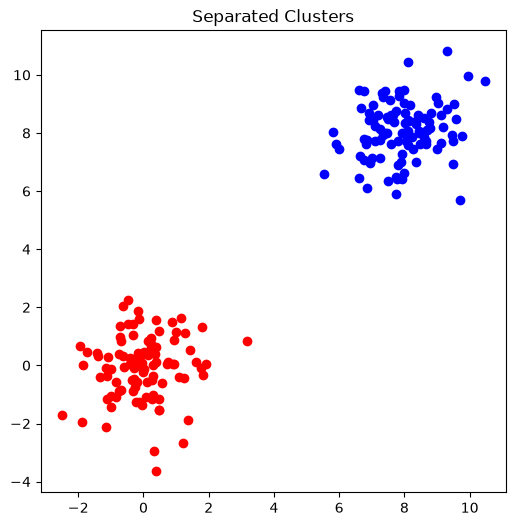

In [6]:
overlap = make_clusters(
    n=100,
    centres=[
        [0, 0],
        [2, 2],
    ],
    spread=2,
)

plt.figure(figsize=(6, 6))

colors = ["red", "blue"]

for cluster, color in zip(overlap, colors):
    plt.scatter(cluster[:, 0], cluster[:, 1], c=color)

plt.title("Overlapping Clusters")
plt.show()


separate = make_clusters(
    n=100,
    centres=[
        [0, 0],
        [8, 8],
    ],
    spread=1,
)

plt.figure(figsize=(6, 6))

for cluster, color in zip(separate, colors):
    plt.scatter(cluster[:, 0], cluster[:, 1], c=color)

plt.title("Separated Clusters")
plt.show()

TASK-05 Break things on purpose


Show that 0.1 + 0.2 != 0.3. Print the actual value with repr to see the error.

• Find two more decimal values whose sum is not exactly what you expect.

• Demonstrate integer overflow: use int8 and produce a wrong, negative result from positive inputs.

• Demonstrate float32 precision loss: find a number where adding 1 changes nothing.

• Demonstrate catastrophic cancellation: subtract two nearly-equal large float32 values and get a badly wrong
answer.

• Sum an array of a million small floats in float32 and in float64. Compare against the exact answer. Which is
closer, and by how much?

• For each pitfall, write one line: how would you detect this in real code, and how would you avoid it?

In [7]:
import numpy as np 


print(0.1 + 0.2 != 0.3)
print(repr(0.1 + 0.2))
print(0.45 + 0.84 == 1.29)    #it gives true value 
print(0.4 + 0.8 == 1.2)       # it gives false value boolean

small = np.array([1, 2, 3], dtype=np.int8)
print(small * 100)

x = np.float32(1e8)
print(np.float32(x + 1) - x)

a = np.float32(100000000.1)
b = np.float32(100000000.0)
print("a - b =", a - b)     #shuould be 0.1

n = 1_000_000

arr32 = np.full(n, 0.1, dtype=np.float32)
arr64 = np.full(n, 0.1, dtype=np.float64)

sum32 = arr32.sum(dtype=np.float32)
sum64 = arr64.sum(dtype=np.float64)

exact = n * 0.1


print(sum32)
print(sum64)
print(exact)

#use float64


True
0.30000000000000004
True
False
[100 -56  44]
0.0
a - b = 0.0
100000.01
100000.00000000003
100000.0


Generate 300 samples with 4 features. Make features 1 and 2 strongly correlated, feature 3 weakly correlated
with them, and feature 4 independent. Seed it.

• Standardise every feature to mean 0 and standard deviation 1. Verify with allclose.

• Compute the covariance matrix as (X.T @ X) / (n - 1). Confirm the shape is 4×4 and that it is symmetric.

• Find its eigenvalues and eigenvectors. Sort them by eigenvalue, descending.

• Report what proportion of total variance each component explains. How many components do you need for
90%?

• Project the data onto the first two components — this is dimensionality reduction. Plot the result.

• Compare your eigenvalues to np.cov(X.T)'s. Do they match?

(300, 4)
[ 0.00315283  0.00453947 -0.00139092 -0.00097194]
[0.92872011 0.89886681 1.0161616  0.97770232]
False
False
eigon Vectors : [[-0.70987143  0.09896164  0.04409152  0.69594906]
 [-0.67986274  0.15166291  0.02931092 -0.71688625]
 [-0.18252751 -0.89816226 -0.39860426 -0.03320988]
 [-0.02351429 -0.40063637  0.9155935  -0.02502252]] eigonvalurs [1.64781862 1.02990418 0.94576944 0.04774748]
[[ 0.86540573  0.78810576  0.10424689  0.02402453]
 [ 0.78810576  0.81066376  0.05428568 -0.00999342]
 [ 0.10424689  0.05428568  1.03603786  0.03254034]
 [ 0.02402453 -0.00999342  0.03254034  0.95909882]]
[3 2 1 0]
[0.44884528 0.28053308 0.25761582 0.01300582]
3
False


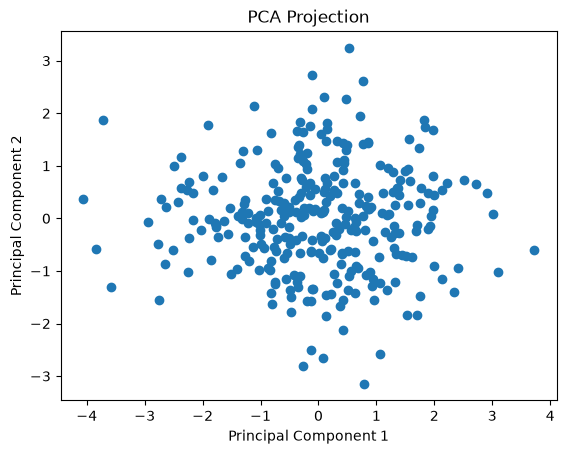

In [8]:
import numpy as np 
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
f1 = rng.normal(0, 1, 300)
f2 = f1 * 0.9 + rng.normal(0, 0.3, 300) # correlated
f3 = f1 * 0.2 + rng.normal(0, 1.0, 300) 
f4 = rng.normal(0, 1, 300) # independent

X = np.column_stack([f1, f2, f3, f4])

print(X.shape)

mean = X.mean(axis = 0)
std = X.std(axis = 0)

X = X-mean/std

print(X.mean(axis=0))
print(X.std(axis=0))
print (np.allclose(X.mean(axis=0), 0))
print ( np.allclose(X.std(axis=0), 1))

n = X.shape[0]

covariance = (X.T @ X) / (n - 1)

eigenvalues, eigenvectors = np.linalg.eig(covariance)
idx = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]
np.argsort(eigenvalues)
explained_variance = eigenvalues / np.sum(eigenvalues)

principle_component = np.argmax(np.cumsum(explained_variance) >= 0.90) + 1 
X_pca = X @ eigenvectors[:, :2]

compare = np.cov(X.T)
print("eigon Vectors :" ,eigenvectors,"eigonvalurs" , eigenvalues)
print(compare)
print (np.argsort(eigenvalues))
print(explained_variance)
print(principle_component)
# print (covariance)
# print (n)
print (np.allclose(eigenvalues , compare))


plt.scatter(X_pca[:, 0], X_pca[:, 1])
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection")
plt.show()